# Architecture Sensitivity Analysis - Google Colab

Random Forest-based feature importance for Transformer architecture parameters.

## Setup: Clean and Clone Repository

In [9]:
# Clean up any existing nested structure
!rm -rf /content/BA
print("Cleaned up any existing repositories")

Cleaned up any existing repositories


In [10]:
import os

repo_url = "https://github.com/bp571/BA"

%cd /content
!git clone {repo_url}
print("\nRepository cloned successfully")

%cd /content/BA
!pwd
print("\nWorking directory set to:", os.getcwd())

/content
Cloning into 'BA'...
remote: Enumerating objects: 427, done.
remote: Counting objects: 100% (427/427), done.
remote: Compressing objects: 100% (300/300), done.
remote: Total 427 (delta 170), reused 354 (delta 97), pack-reused 0 (from 0)
Receiving objects: 100% (427/427), 10.54 MiB | 20.63 MiB/s, done.
Resolving deltas: 100% (170/170), done.

Repository cloned successfully
/content/BA
/content/BA

Working directory set to: /content/BA


## Set API Key

The data loader requires a Tiingo API key. Get one free at: https://www.tiingo.com/

In [11]:
import os
from pathlib import Path

# Set your Tiingo API key here
TIINGO_API_KEY = "312c6dab6a1fe6258bbc6652bcdec49a14ee08ad"

# Set environment variable for the session
os.environ["TIINGO_API_KEY"] = TIINGO_API_KEY

# Create .env file for compatibility
env_content = f"TIINGO_API_KEY={TIINGO_API_KEY}\n"
Path(".env").write_text(env_content)

print("✅ API key configured")

✅ API key configured


## Clone Kronos Model

Kronos is not included in the repo (gitignored), so clone it separately.

In [12]:
# Clone Kronos model into the expected location
!git clone https://github.com/shiyu-coder/Kronos.git 02_finetuning/models/Kronos
print("\nKronos model cloned successfully")
!ls -la 02_finetuning/models/

Cloning into '02_finetuning/models/Kronos'...
remote: Enumerating objects: 316, done.
remote: Counting objects: 100% (203/203), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 316 (delta 143), reused 129 (delta 129), pack-reused 113 (from 2)
Receiving objects: 100% (316/316), 6.24 MiB | 23.31 MiB/s, done.
Resolving deltas: 100% (167/167), done.

Kronos model cloned successfully
total 16
drwxr-xr-x  4 root root 4096 Mar 26 17:18 .
drwxr-xr-x  5 root root 4096 Mar 26 17:18 ..
drwxr-xr-x 10 root root 4096 Mar 26 17:19 Kronos
drwxr-xr-x  7 root root 4096 Mar 26 17:18 model_cache


## Install Dependencies

In [13]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q pandas numpy matplotlib seaborn scikit-learn tqdm yfinance einops peft transformers huggingface_hub chronos-forecasting python-dotenv

In [14]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA A100-SXM4-80GB


## Step 1: Random Search

Sample architecture parameters and evaluate models.

In [15]:
n_samples = 150
seed = 42

!python 03_sensitivity_analysis/architecture_parameters/run_architecture_search.py \
    --n-samples {n_samples} \
    --seed {seed}

✅ Random Seeds auf 42 gesetzt für Reproduzierbarkeit
Architecture Sensitivity Analysis
Samples: 150
Device: cuda

Loaded 3 assets

Random Search: 100% 150/150 [01:02<00:00,  2.40it/s]

Completed: 150/150 successful
Results saved: 03_sensitivity_analysis/architecture_parameters/results/architecture_search_150.csv

Next: python 03_sensitivity_analysis/architecture_parameters/analyze_rf.py


## Step 2: Random Forest Analysis

Train Random Forest and extract feature importances.

In [16]:
!python 03_sensitivity_analysis/architecture_parameters/analyze_rf.py

Random Forest Analysis - Architecture Parameters
Loaded 150 samples


MAE:
------------------------------------------------------------
  d_model        : 0.2691
  num_heads      : 0.2318
  num_layers     : 0.2653
  dropout        : 0.2338

Plot saved: 03_sensitivity_analysis/architecture_parameters/results/rf_importance_mae.png

RANKIC:
------------------------------------------------------------
  d_model        : 0.2857
  num_heads      : 0.1942
  num_layers     : 0.3079
  dropout        : 0.2121

Plot saved: 03_sensitivity_analysis/architecture_parameters/results/rf_importance_rankic.png

Analysis complete


## Step 3: Display Results

In [17]:
import pandas as pd
from IPython.display import Image, display

df = pd.read_csv(f"03_sensitivity_analysis/architecture_parameters/results/architecture_search_{n_samples}.csv")
print(f"Results: {len(df)} samples\n")
print(df.describe())
print("\nSample rows:")
display(df.head(10))

Results: 150 samples

         d_model   num_heads  num_layers     dropout         mae      rankic
count  150.00000  150.000000  150.000000  150.000000  150.000000  150.000000
mean    61.12000    4.586667    2.480000    0.210667    4.223380   -0.019616
std     43.27808    2.616896    1.078901    0.082857    0.254466    0.041820
min     16.00000    2.000000    1.000000    0.100000    3.761953   -0.120047
25%     32.00000    2.000000    2.000000    0.100000    4.036074   -0.044172
50%     64.00000    4.000000    2.000000    0.200000    4.194675   -0.015035
75%    128.00000    8.000000    3.000000    0.300000    4.340389    0.004895
max    128.00000    8.000000    4.000000    0.300000    5.209885    0.128205

Sample rows:


,d_model,num_heads,num_layers,dropout,mae,rankic
0,16,2,3,0.1,4.111549,-0.078788
1,32,2,1,0.3,4.421826,-0.040793
2,16,8,4,0.1,4.338882,-0.081585
3,16,2,2,0.1,3.974847,-0.031002
4,16,8,2,0.3,4.187437,-0.072028
5,128,2,4,0.3,4.180308,-0.043590
6,64,2,2,0.3,4.178251,0.005594
7,128,4,3,0.1,4.467485,0.044056
8,32,4,1,0.1,4.016381,-0.027739
9,128,2,3,0.2,4.226677,-0.028671


Feature Importance - MAE:


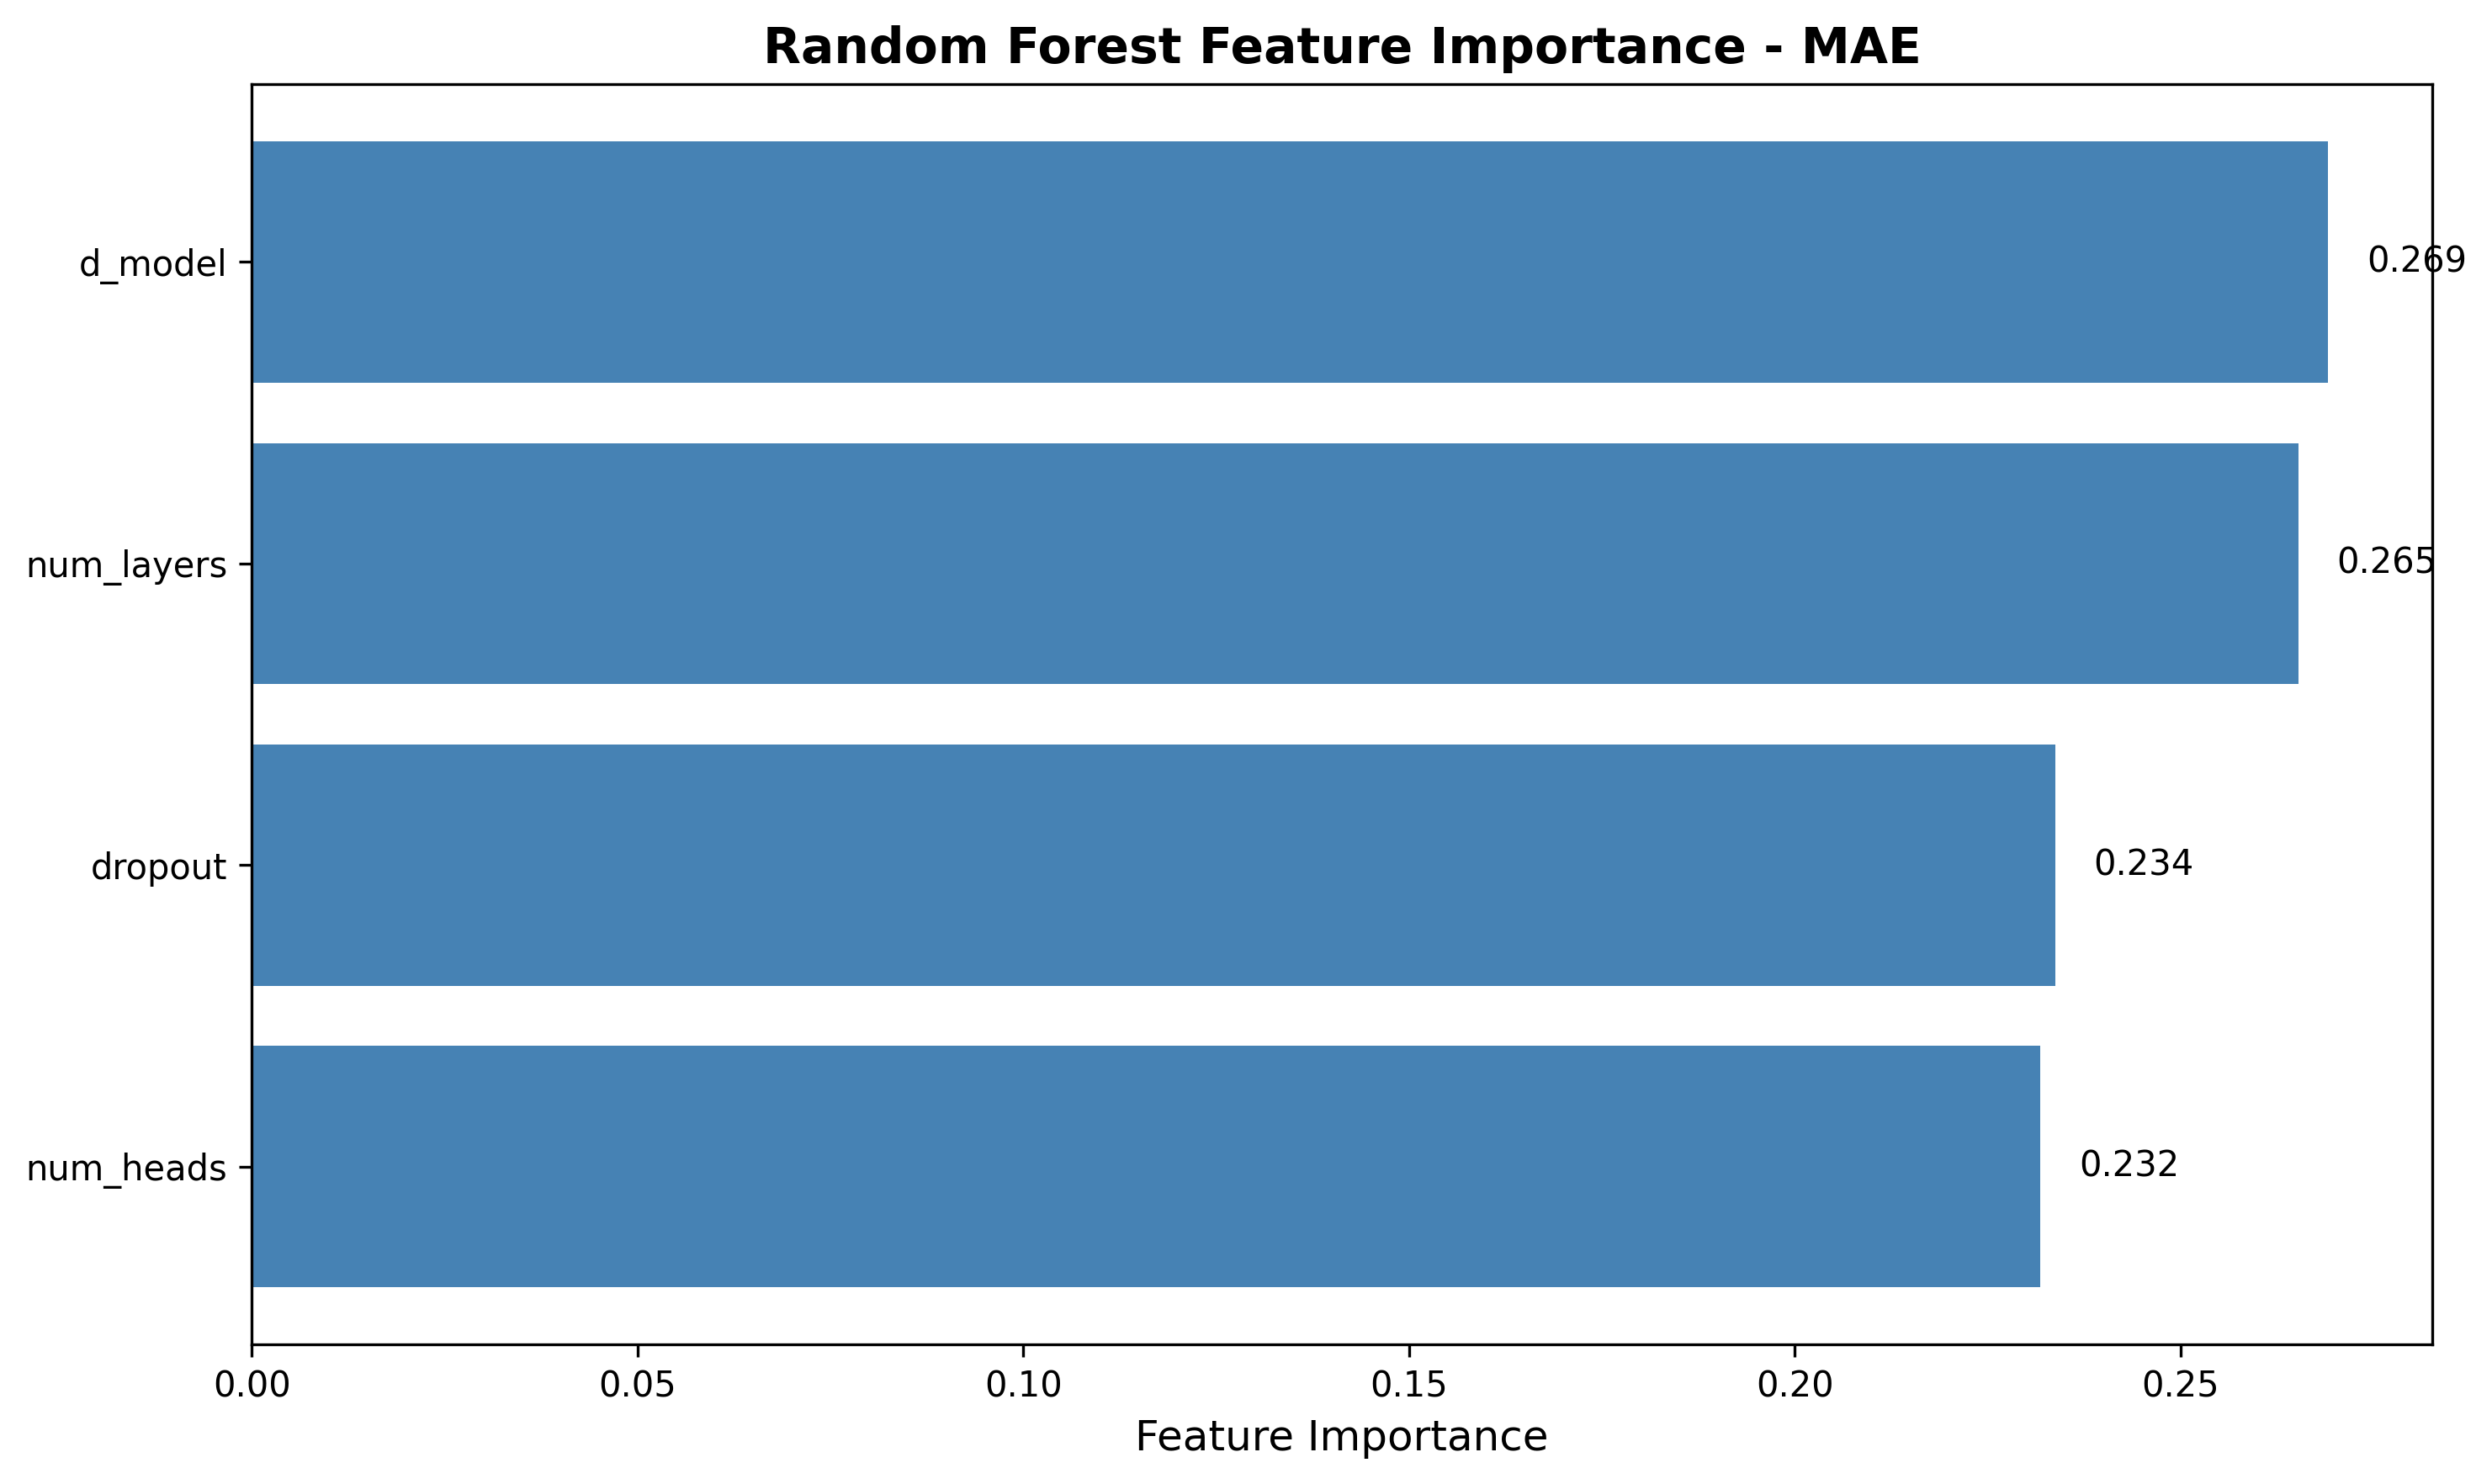


Feature Importance - RankIC:


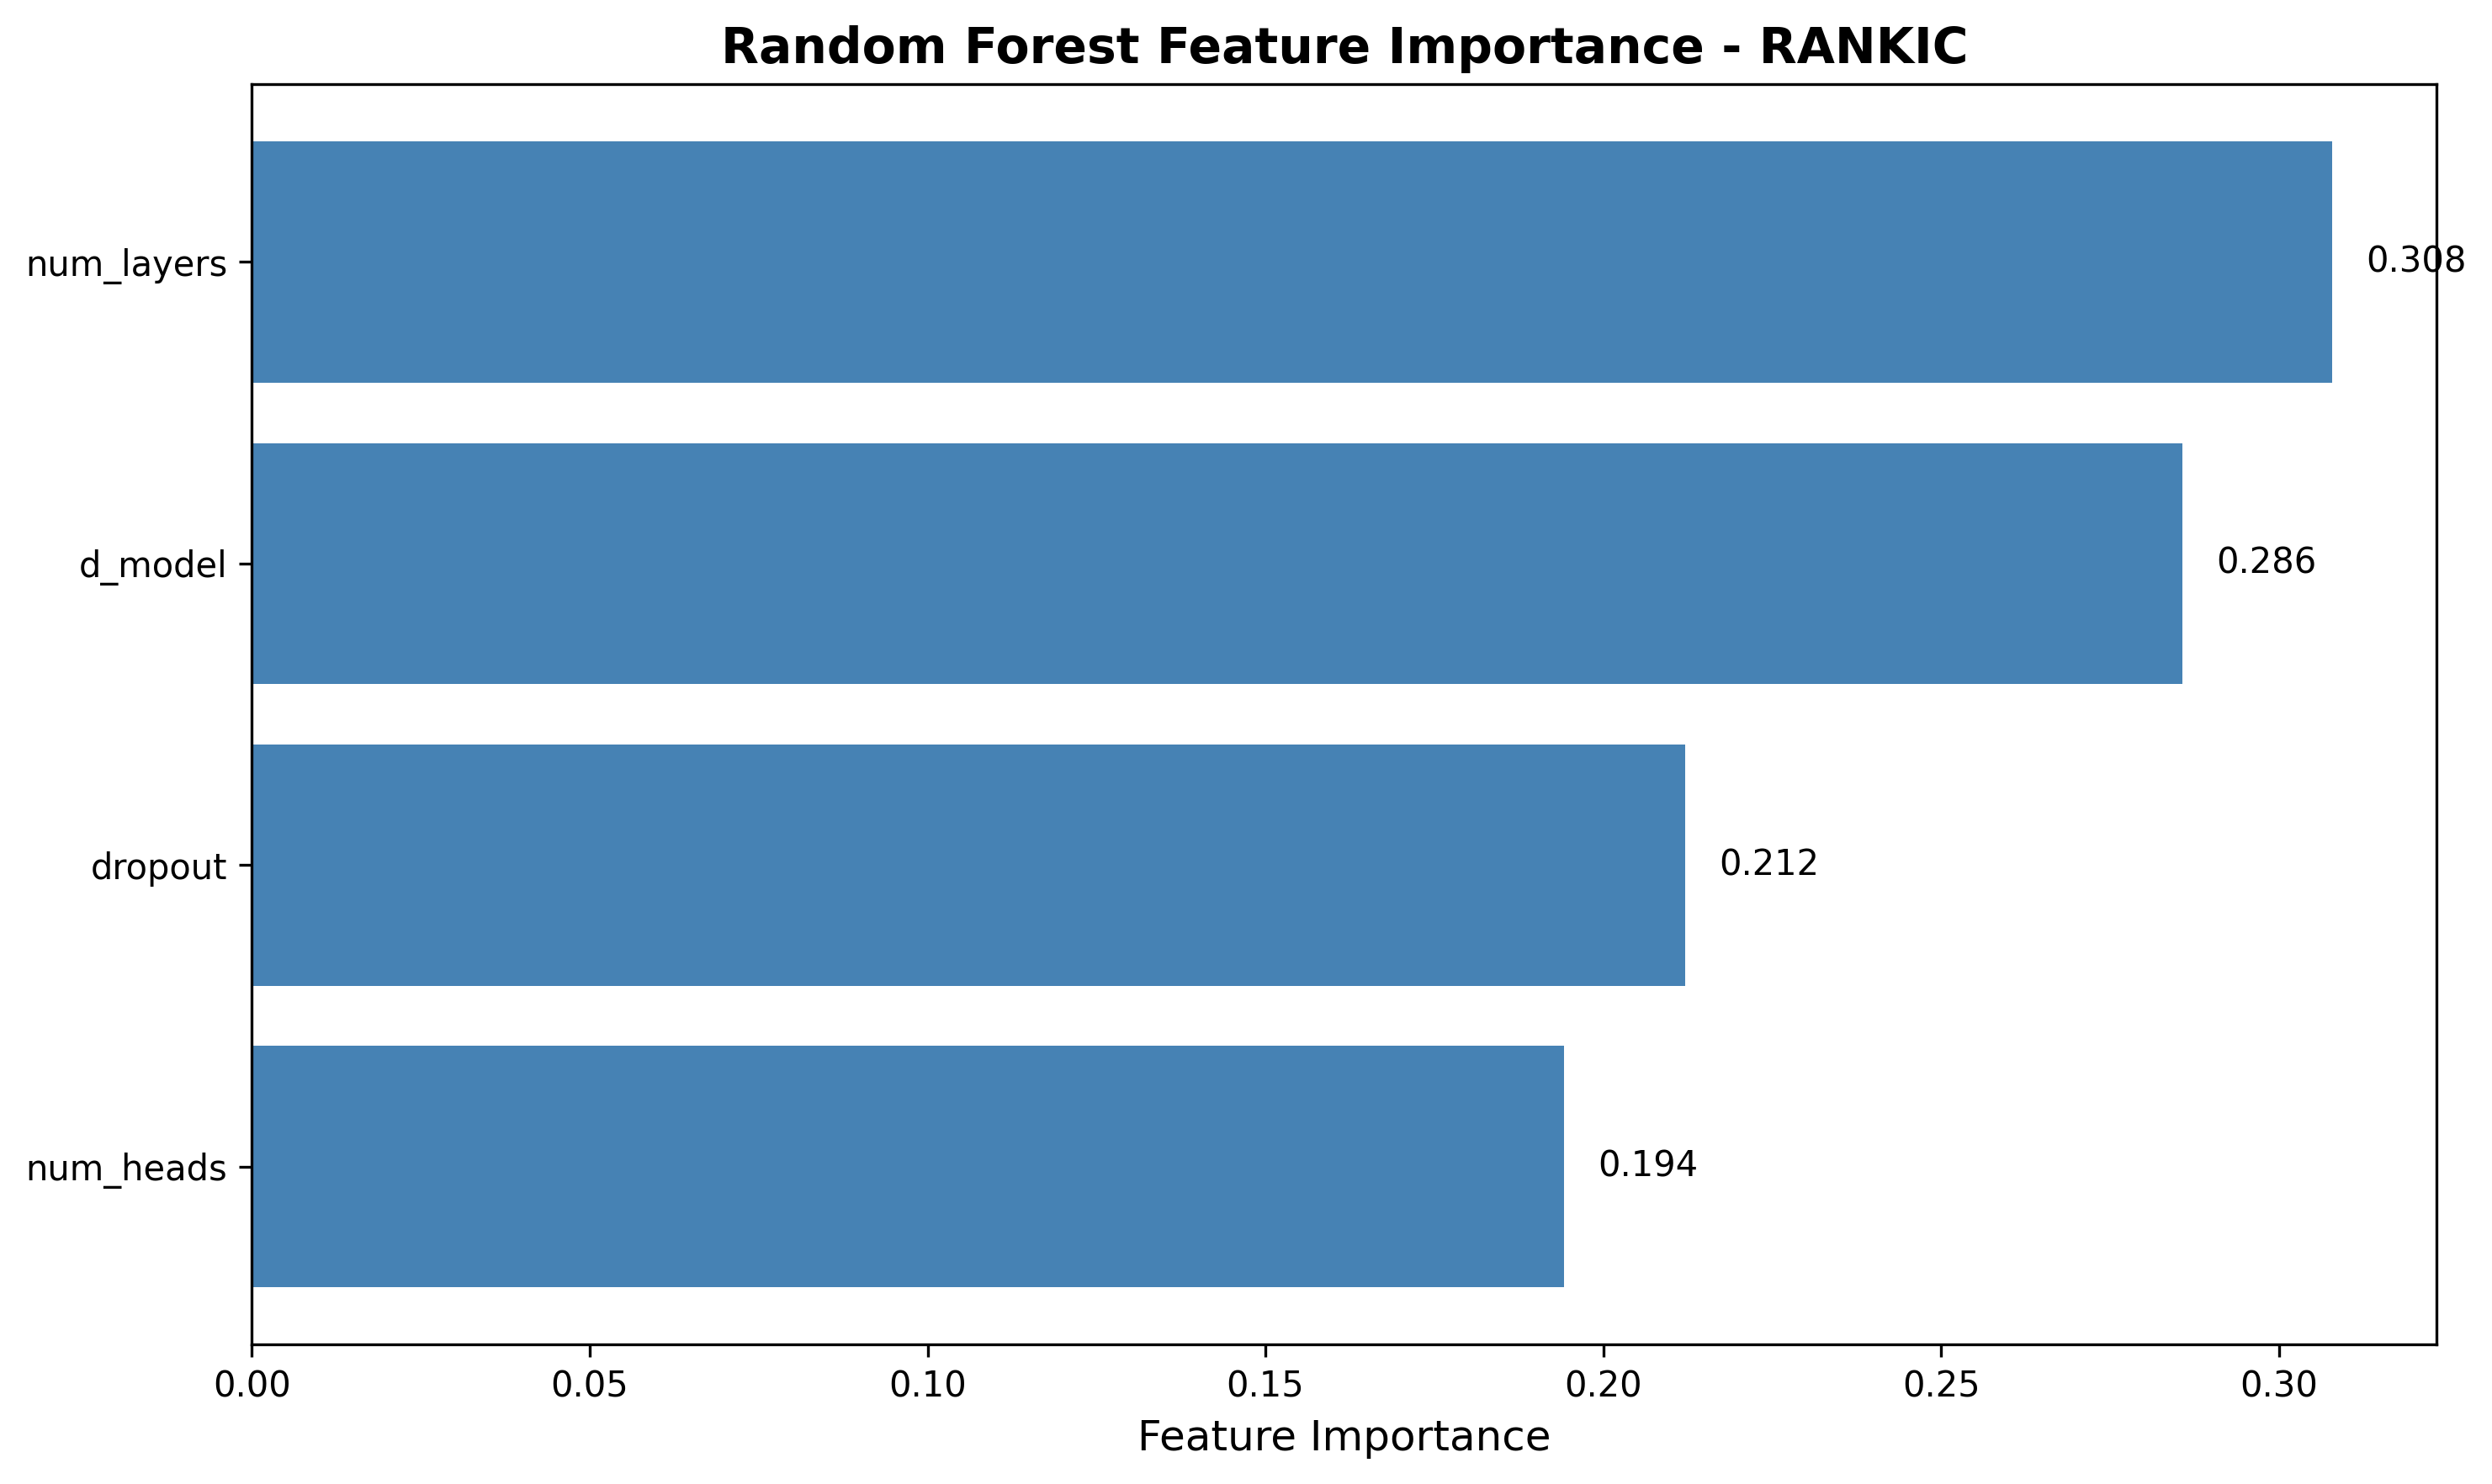

In [18]:
print("Feature Importance - MAE:")
display(Image("03_sensitivity_analysis/architecture_parameters/results/rf_importance_mae.png"))

print("\nFeature Importance - RankIC:")
display(Image("03_sensitivity_analysis/architecture_parameters/results/rf_importance_rankic.png"))

## Step 4: Download Results

In [19]:
from google.colab import files
import zipfile

zip_name = "architecture_sensitivity_results.zip"

with zipfile.ZipFile(zip_name, 'w') as zipf:
    zipf.write(f"03_sensitivity_analysis/architecture_parameters/results/architecture_search_{n_samples}.csv",
               arcname=f"architecture_search_{n_samples}.csv")
    zipf.write("03_sensitivity_analysis/architecture_parameters/results/rf_importance_mae.png",
               arcname="rf_importance_mae.png")
    zipf.write("03_sensitivity_analysis/architecture_parameters/results/rf_importance_rankic.png",
               arcname="rf_importance_rankic.png")

files.download(zip_name)
print(f"Downloaded: {zip_name}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: architecture_sensitivity_results.zip
